In [ ]:
from langgraph.graph import StateGraph
from langgraph.graph import MessageGraph

In [ ]:
from langchain_groq import ChatGroq

In [ ]:
# now we will import the model
# Change this:
llm = ChatGroq(model="llama3-70b-8192")

# To a currently supported model like Llama 3.3 70B:
llm = ChatGroq(model="llama-3.3-70b-versatile") 

# Alternatively, for a faster/smaller model you 

In [ ]:
llm.invoke("hi how are u?")

AIMessage(content="Hello. I'm doing well, thanks for asking. I'm a large language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to assist you with any questions or tasks you may have. How can I help you today?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 57, 'prompt_tokens': 40, 'total_tokens': 97, 'completion_time': 0.107200147, 'completion_tokens_details': None, 'prompt_time': 0.008116599, 'prompt_tokens_details': None, 'queue_time': 0.161309108, 'total_time': 0.115316746}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e2754-fa38-7631-8f6d-1c266cd043f2-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 40, 'output_tokens': 57, 'total_tokens': 97})

In [ ]:
llm.invoke("hi how are u?").content

"Hello. I'm just a language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to help with any questions or tasks you may have. How can I assist you today?"

In [ ]:
def function1(input):
    llm=ChatGroq(model="llama-3.3-70b-versatile")
    response = llm.invoke("hi how are u").content
    return response

In [ ]:
function1("hi")

"I'm doing well, thanks for asking. I'm a large language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to help with any questions or tasks you may have. How about you? How's your day going so far?"

In [ ]:
def function2(input):
    upper_string = input.upper()
    return upper_string 

In [ ]:
from typing import TypedDict

class State(TypedDict):
    messages: list

workflow = StateGraph(State)


In [ ]:
"""from langgraph.graph import START, END
# 1. Define a function for your node. 
# This function receives the current "state", calls your LLM, and returns the response.
def call_model(state: State):
    # Pass the messages from the state to the model
    response = llm.invoke(state["messages"])
    # Return the new message to append to the state
    return {"messages": [response]}
# 2. Add the node to your workflow. 
# "assistant" is the name we give the node, and `call_model` is the function it runs.
workflow.add_node("assistant", call_model)
# 3. Add edges to define the flow.
# Tell the graph to start at the "assistant" node...
workflow.add_edge(START, "assistant")
# ...and finish after the "assistant" node is done.
workflow.add_edge("assistant", END)

 LangGraph needs to know the name of the node, and the function it should run. 
For an edge, it needs to know the starting point and ending point."""
"""  A graph is like a map. LangGraph needs to know exactly which node is the starting point (the entrypoint) using the special START variable."""


'  A graph is like a map. LangGraph needs to know exactly which node is the starting point (the entrypoint) using the special START variable.'

In [ ]:
"""# 4. Compile the workflow into an executable app!
app = workflow.compile()
# 5. Invoke the app with your starting message
response = app.invoke({"messages": ["hi"]})
# Print the final output from the AI
print(response["messages"][-1].content)"""

It's nice to meet you. Is there something I can help you with or would you like to chat?


In [ ]:
from typing import TypedDict
from langgraph.graph import StateGraph

class State(TypedDict):
    text: str

def function1(state: State):
    response = llm.invoke(state["text"])
    return {"text": response.content}

def function2(state: State):
    return {"text": state["text"].upper()}

workflow = StateGraph(State)

workflow.add_node("llm", function1)
workflow.add_node("upper_string", function2)
workflow.add_edge("llm", "upper_string")

workflow.set_entry_point("llm")
workflow.set_finish_point("upper_string")

app = workflow.compile()
output = app.invoke({"text": "hi how are you"})

print(output["text"])


HELLO. I'M JUST A LANGUAGE MODEL, SO I DON'T HAVE FEELINGS OR EMOTIONS LIKE HUMANS DO, BUT I'M FUNCTIONING PROPERLY AND READY TO ASSIST YOU. HOW CAN I HELP YOU TODAY?


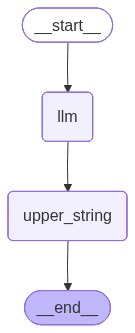

In [ ]:

from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e) # whole visualization 

In [ ]:
app.invoke({"text": "hi"})


{'text': "IT'S NICE TO MEET YOU. IS THERE SOMETHING I CAN HELP YOU WITH OR WOULD YOU LIKE TO CHAT?"}

In [ ]:
app.invoke({"text": "who is avneet kaur"})


{'text': "AVNEET KAUR IS AN INDIAN ACTRESS, DANCER, AND SOCIAL MEDIA INFLUENCER. SHE WAS BORN ON OCTOBER 13, 2001, IN JALANDHAR, PUNJAB, INDIA. AVNEET BEGAN HER CAREER AS A CHILD ARTIST AND GAINED POPULARITY FOR HER ROLES IN VARIOUS INDIAN TELEVISION SHOWS AND FILMS.\n\nSOME OF HER NOTABLE WORKS INCLUDE:\n\n1. **DANCE INDIA DANCE LI'L MASTERS** (2010) - AVNEET WAS A CONTESTANT ON THIS DANCE REALITY SHOW AND FINISHED AS A FINALIST.\n2. **MERI MAA** (2011) - SHE PLAYED THE LEAD ROLE OF JHILMIL IN THIS TELEVISION SERIES.\n3. **TEDHE MEDHE SAPNE** (2012) - AVNEET PLAYED THE ROLE OF PINKY IN THIS TV SHOW.\n4. **SAVITRI** (2013) - SHE PLAYED THE ROLE OF YOUNG SAVITRI IN THIS MYTHOLOGICAL TV SERIES.\n5. **HAMARI SISTER DIDI** (2014) - AVNEET PLAYED THE ROLE OF KHUSHI IN THIS TV SHOW.\n6. **CHANDRA NANDINI** (2016-2017) - SHE PLAYED THE ROLE OF CHARUMATI IN THIS HISTORICAL DRAMA TV SERIES.\n7. **ALADDIN - NAAM TOH SUNA HOGA** (2018-2020) - AVNEET PLAYED THE LEAD ROLE OF PRINCESS YASMINE IN THI